In [1]:
# ============================================================
# SETUP PATHS & IMPORTS
# ============================================================
import importlib
import os
import sys
import warnings
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["ABSL_LOG_LEVEL"] = "3"

# 1. LOCAL DYNAMIC PATH ROUTING
current_dir = os.getcwd()
workspace_root = current_dir
if os.path.basename(current_dir) == "notebooks":
    workspace_root = os.path.dirname(current_dir)
src_path = os.path.join(workspace_root, "src")
sys.path.insert(0, workspace_root)
sys.path.insert(0, src_path)

# 2. KAGGLE SPECIFIC PATH ROUTING
try:
    dataset_name = os.listdir("/kaggle/input/datasets/keithmarange")[0]
    sys.path.append(f"/kaggle/input/datasets/keithmarange/{dataset_name}/")
    sys.path.append("/kaggle/input/cmi-competition-code/")
except Exception:
    pass

try:
    import tensorflow as tf
    tf.get_logger().setLevel("ERROR")
    TF_AVAILABLE = True
except Exception as exc:
    tf = None
    TF_AVAILABLE = False
    print(f"TensorFlow unavailable: {exc}. Continuing with the sklearn-compatible multibranch classifier.")

from sklearn.metrics import classification_report, f1_score, make_scorer
from sklearn.model_selection import GridSearchCV, GroupKFold, GroupShuffleSplit
from sklearn.pipeline import Pipeline

try:
    from skopt import BayesSearchCV
    from skopt.space import Categorical, Integer, Real
    SKOPT_AVAILABLE = True
except ImportError:
    SKOPT_AVAILABLE = False

# 3. IMPORTS FROM PROJECT MODULES
try:
    from src import data_utils
    from src.base_utils_qwen import SequenceExtractor, competition_scorer, evaluate_holdout, prepare_bayesian_space
    import src.multibranch_v2 as multibranch_module
    importlib.reload(multibranch_module)
    from src.multibranch_v2 import FeatureAwarePipeline, KerasFlexibleMultiBranchClassifier
    print("✅ Imports loaded from src/")
except ImportError:
    try:
        import data_utils
        from base_utils_qwen import SequenceExtractor, competition_scorer, evaluate_holdout, prepare_bayesian_space
        from multibranch_v2 import FeatureAwarePipeline, KerasFlexibleMultiBranchClassifier
        print("✅ Imports loaded flattened")
    except ImportError as e:
        print(f"❌ Import failed: {e}")
        raise

✅ Imports loaded flattened


In [2]:
# ============================================================
# CONFIGURATION & DATA LOADING
# ============================================================
TARGET_COL = "bfrb" # or "gesture_action"
pipe_name = "extractor"
clf_name = "classifier"

search_mode = "bayesian" 
random_state = 42
n_splits = 3
n_iter = 30
train_size = 0.4
error_score_constant = 0.0
verbose = 3
do_cross_val = False
validation_split = max(0.2, 1 - train_size)


In [3]:
if do_cross_val:
    cv_object = GroupKFold(n_splits=n_splits)
else:
    cv_object = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=random_state)

scorer = competition_scorer
results_dir = Path("results")
results_dir.mkdir(exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

# Load Data
data_root = data_utils.find_data_root()
raw_train_df = pd.read_csv(data_root / "train.csv")
train_df = raw_train_df.set_index("row_id").copy()

# Target Engineering
train_df["gesture_action"] = train_df["gesture"].str.split(" - ").str[-1]
train_df["orientation"] = train_df["orientation"].fillna("Unknown")
train_df["is_target"] = train_df["sequence_type"].eq("Target").astype(int)

# CRITICAL FIX: Create the 'bfrb' column if needed
if TARGET_COL == "bfrb":
    train_df["bfrb"] = train_df["gesture"].where(train_df["is_target"].astype(bool), "non_bfrb")

# Split with Fallback
try:
    train_sample_df, hold_out_df = data_utils.sample_balanced_split(
        train_df, train_pct=train_size, test_pct=validation_split, random_state=random_state
    )
except ValueError as exc:
    print(f"Balanced split unavailable ({exc}); using simple sequence split.")
    unique_seqs = train_df[["sequence_id", TARGET_COL]].drop_duplicates("sequence_id").sample(frac=1, random_state=random_state)
    n_train = max(1, int(len(unique_seqs) * train_size))
    train_seqs = unique_seqs.iloc[:n_train]["sequence_id"]
    test_seqs = unique_seqs.iloc[n_train:]["sequence_id"]
    train_sample_df = train_df[train_df["sequence_id"].isin(train_seqs)].copy()
    hold_out_df = train_df[train_df["sequence_id"].isin(test_seqs)].copy()

X_train, X_test = train_sample_df, hold_out_df
y_train = X_train[["sequence_id", "is_target", TARGET_COL]].copy()
y_test  = X_test[["sequence_id", "is_target", TARGET_COL]].copy()
groups = X_train["sequence_id"]

print(f"Train sequences: {X_train['sequence_id'].nunique()} | Test sequences: {X_test['sequence_id'].nunique()}")

✅ Using Kaggle data folder: /kaggle/input/competitions/cmi-detect-behavior-with-sensor-data
Train: 2910 seqs | 35.7%
Test:  2881 seqs  | 35.3%
Train sequences: 2910 | Test sequences: 2881


In [4]:
# ============================================================
# PIPELINE SETUP
# ============================================================

pipeline = FeatureAwarePipeline([
    (pipe_name, SequenceExtractor(
        acc_modes="raw|velocity|jerk",

    )),
    (clf_name, KerasFlexibleMultiBranchClassifier(
        primary_target=TARGET_COL,
        verbose=0
    ))
])

In [5]:
if search_mode == "bayesian" and SKOPT_AVAILABLE:
    param_space = {
        # --- EXTRACTOR: Physics & Preprocessing ---
        f"{pipe_name}__acc_modes": Categorical(["raw"]),
        f"{pipe_name}__rotation_modes": Categorical(["raw"]),
        f"{pipe_name}__tof_modes": Categorical(["raw",
    "centered",
    "diff",
    "centered_diff",
    "pooled_stats",
    "raw|centered",
    "raw|diff",
    "raw|centered_diff",
    "raw|pooled_stats",
    "centered|diff",
    "centered|centered_diff",
    "centered|pooled_stats",
    "diff|centered_diff",
    "diff|pooled_stats",
    "centered_diff|pooled_stats",
    "raw|centered|diff",
    "raw|centered|centered_diff",
    "raw|centered|pooled_stats",
    "raw|diff|centered_diff",
    "raw|diff|pooled_stats",
    "raw|centered_diff|pooled_stats",
    "centered|diff|centered_diff",          # ⚠️ problematic – caused the crash
    "centered|diff|pooled_stats",
    "centered|centered_diff|pooled_stats",
    "diff|centered_diff|pooled_stats",
    "raw|centered|diff|centered_diff",
    "raw|centered|diff|pooled_stats",
    "raw|centered|centered_diff|pooled_stats",
    "raw|diff|centered_diff|pooled_stats",
    "centered|diff|centered_diff|pooled_stats",
    "raw|centered|diff|centered_diff|pooled_stats"
                                               ]),
        f"{pipe_name}__thm_modes": Categorical(["diff", "centered_diff"]),
        f"{pipe_name}__motion_filter_mode": Categorical([None]),
        f"{pipe_name}__use_dead_reckoning": Categorical([False]),
        f"{pipe_name}__dead_reckoning_detrend": Categorical([False]),
        f"{pipe_name}__interp_mode": Categorical(["linear"]),
        f"{pipe_name}__clip_value": Categorical([None]),
        
        # --- EXTRACTOR: Chunking & Sampling (FIXED: Added native rates) ---
        f"{pipe_name}__chunk_window_size": Categorical([180]),
        f"{pipe_name}__chunk_stride": Categorical([100]),
        
        f"{pipe_name}__imu_native_sampling_rate": Categorical([100]),
        f"{pipe_name}__rot_native_sampling_rate": Categorical([100]),
        f"{pipe_name}__tof_native_sampling_rate": Categorical([100]),
        f"{pipe_name}__thm_native_sampling_rate": Categorical([100]),
        
        f"{pipe_name}__imu_target_sampling_rate": Categorical([100]),
        f"{pipe_name}__rot_target_sampling_rate": Categorical([100]),
        f"{pipe_name}__tof_target_sampling_rate": Categorical([100]),
        f"{pipe_name}__thm_target_sampling_rate": Categorical([100]),
        
        f"{pipe_name}__kalman_process_noise": Categorical([0.0]),
        f"{pipe_name}__kalman_measurement_noise": Categorical([0.0]),
        f"{pipe_name}__smooth_alpha": Categorical([0.0]),
        
        # --- CLASSIFIER: Backbone & Architecture (FIXED: Correct names) ---
        f"{clf_name}__backbone_type": Categorical(["1dcnn"]), # Was: backbone_type
        f"{clf_name}__branch_filters": Categorical([
            '{"acc": "64", "rot": "64", "thm": "64", "tof": "64"}',
            '{"acc": "64", "rot": "64", "thm": "64", "tof": "64-64"}',
            '{"acc": "64", "rot": "64", "thm": "64", "tof": "128"}',
            '{"acc": "64", "rot": "64", "thm": "64", "tof": "128-128"}',
            '{"acc": "64", "rot": "64", "thm": "64", "tof": "128-256"}',
            '{"acc": "64", "rot": "64", "thm": "64", "tof": "64-128-128"}'
        ]),
        f"{clf_name}__branch_kernel_sizes": Categorical([
            '{"acc": "5-5", "rot": "5", "thm": "3", "tof": "3"}',
            '{"acc": "5-5", "rot": "5", "thm": "3", "tof": "3-3"}',
            '{"acc": "5-5", "rot": "5", "thm": "3", "tof": "3-3-3"}'
        ]),
        f"{clf_name}__attention_heads": Categorical([4]),
        f"{clf_name}__gru_units": Categorical([30]), # Was: gru_units
        
        # --- CLASSIFIER: SE Fusion & Post-BiGRU (FIXED: Correct types) ---
        f"{clf_name}__se_ratio": Categorical([4]),
        f"{clf_name}__use_post_bigru": Categorical([False]), # Was: 0.0 (Must be bool)
        f"{clf_name}__post_gru_units": Categorical([128]),   # Was: 0.0 (Must be int)
        f"{clf_name}__use_batch_norm": Categorical([False]),
        
        # --- CLASSIFIER: Training Dynamics & Regularization ---
        f"{clf_name}__spatial_dropout": Categorical([0.0]),
        f"{clf_name}__dropout": Categorical([0.0]),
        f"{clf_name}__learning_rate": Categorical([5e-3]),
        f"{clf_name}__batch_size": Categorical([16]),
        f"{clf_name}__epochs": Categorical([50]),
        f"{clf_name}__patience": Categorical([20]),
        f"{clf_name}__verbose": Categorical([verbose])             # Fixed
    }

else: # Grid Search
    param_space = {
        f"{pipe_name}__acc_modes": ["smoothed|velocity|jerk"],
        f"{pipe_name}__rotation_modes": ["quaternion|angular_velocity"],
        f"{pipe_name}__tof_modes": ["pooled_stats"],
        f"{pipe_name}__thm_modes": ["centered_diff"],
        f"{pipe_name}__motion_filter_mode": ["extended_kalman"],
        f"{pipe_name}__use_dead_reckoning": [True],
        
        # --- EXTRACTOR: Chunking & Sampling (FIXED: Added native rates) ---
        f"{pipe_name}__chunk_window_size": [160],
        f"{pipe_name}__chunk_stride": [120],
        f"{pipe_name}__padding_value": [0.0],
        
        f"{pipe_name}__imu_native_sampling_rate": [20],
        f"{pipe_name}__rot_native_sampling_rate": [20],
        f"{pipe_name}__tof_native_sampling_rate": [5],
        f"{pipe_name}__thm_native_sampling_rate": [5],
        
        f"{pipe_name}__imu_target_sampling_rate": [100],
        f"{pipe_name}__rot_target_sampling_rate": [100],
        f"{pipe_name}__tof_target_sampling_rate": [10],
        f"{pipe_name}__thm_target_sampling_rate": [10],
        
        # --- CLASSIFIER: Backbone & Architecture (FIXED: Correct names) ---
        f"{clf_name}__backbone_type": ['1dcnn', "attention", "gru", "2dcnn"], # Was: backbone_type
        f"{clf_name}__branch_filters": ['{"acc": "16", "rot": "16", "thm": "16", "tof": "16"}'],
        f"{clf_name}__branch_kernel_sizes": ['{"acc": "3", "rot": "3", "thm": "3", "tof": "3"}'],
        f"{clf_name}__gru_units": [128], # Was: gru_units
        
        # --- CLASSIFIER: SE Fusion & Regularization ---
        f"{clf_name}__se_ratio": [4],
        f"{clf_name}__use_post_bigru": [True],
        f"{clf_name}__post_gru_units": [128],
        f"{clf_name}__use_batch_norm": [True],
        f"{clf_name}__dropout": [0.0],
        f"{clf_name}__l2_reg": [1e-4],    # Added
        f"{clf_name}__learning_rate": [5e-3],
        f"{clf_name}__batch_size": [32],
        f"{clf_name}__epochs": [100],
        f"{clf_name}__patience": [10],
        f"{clf_name}__validation_split": [0.15], # Added
        f"{clf_name}__random_state": [42],      # Added
        f"{clf_name}__verbose": [verbose]       # Fixed: Removed erroneous Categorical() wrapper
    }

In [6]:
# ============================================================
# SEARCH EXECUTION
# ============================================================
if search_mode == "bayesian" and SKOPT_AVAILABLE:
    search = BayesSearchCV(
        estimator=pipeline, search_spaces=param_space, n_iter=n_iter,
        scoring=competition_scorer, cv=cv_object, n_jobs=1,
        random_state=random_state, verbose=verbose, refit=True,
        return_train_score=True, error_score=error_score_constant
    )
else:
    search = GridSearchCV(
        estimator=pipeline, param_grid=param_space, scoring=competition_scorer,
        cv=cv_object, n_jobs=1, verbose=verbose, refit=True,
        return_train_score=True, error_score=error_score_constant
    )

print(f"🚀 Running {search_mode} search...")
print(f"Estimator class: {type(pipeline.named_steps['classifier']).__name__}")
search.fit(X_train, y_train, groups=groups)

print(f"\n🏆 Best CV competition score: {search.best_score_:.4f}")
print("Best parameters:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")
    
best_model = search.best_estimator_

🚀 Running bayesian search...
Estimator class: KerasFlexibleMultiBranchClassifier
Fitting 1 folds for each of 1 candidates, totalling 1 fits


I0000 00:00:1785006719.811788      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785006719.814483      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/50


I0000 00:00:1785006729.225250      69 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Epoch 2/50
Epoch 3/50
Epoch 4/50
Epoch 5/50
Epoch 6/50
Epoch 7/50
Epoch 8/50
Epoch 9/50
Epoch 10/50
Epoch 11/50
Epoch 12/50
Epoch 13/50
Epoch 14/50
Epoch 15/50
Epoch 16/50
Epoch 17/50
Epoch 18/50
Epoch 19/50
Epoch 20/50
Epoch 21/50
Epoch 22/50
Epoch 23/50
Epoch 24/50
Epoch 25/50
Epoch 26/50
Epoch 27/50
Epoch 28/50
Epoch 29/50
Epoch 30/50
Epoch 31/50
Epoch 32/50
Epoch 33/50
Epoch 34/50
Epoch 35/50
Epoch 36/50
Epoch 37/50
Epoch 38/50
Epoch 39/50
Epoch 40/50
Epoch 41/50
Epoch 42/50
Epoch 43/50
Epoch 44/50
Epoch 45/50
Epoch 46/50
Epoch 47/50
Epoch 48/50
Epoch 49/50
Epoch 50/50
[CV 1/1] END classifier__attention_heads=4, classifier__backbone_type=1dcnn, classifier__batch_size=16, classifier__branch_filters={"acc": "64", "rot": "64", "thm": "64", "tof": "64-64"}, classifier__branch_kernel_sizes={"acc": "5-5", "rot": "5", "thm": "3", "tof": "3-3-3"}, classifier__dropout=0.0, classifier__epochs=50, classifier__gru_units=30, classifier__learning_rate=0.005, classifier__patience=20, classifier__

🚀 Analyzing Best Model & Evaluating on Holdout Set...
📈 Plotting Training & Validation Curves...



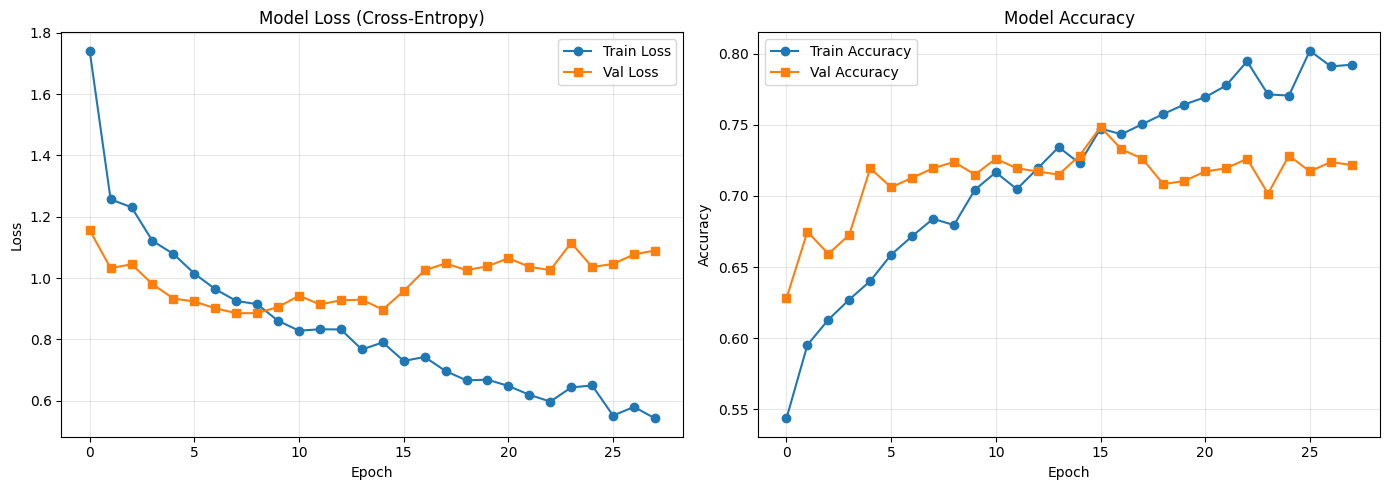

In [7]:
# ============================================================
# MODEL ANALYSIS, TRAINING CURVES & HOLDOUT EVALUATION
# ============================================================
print("🚀 Analyzing Best Model & Evaluating on Holdout Set...")

# 1. Extract the best fitted pipeline
best_pipeline = search.best_estimator_
best_classifier = best_pipeline.named_steps['classifier']

# 2. Plot Training & Validation Curves
if hasattr(best_classifier, 'history_'):
    print("📈 Plotting Training & Validation Curves...\n")
    history = best_classifier.history_
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss Curve
    axes[0].plot(history['loss'], label='Train Loss', marker='o')
    if 'val_loss' in history:
        axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
    axes[0].set_title('Model Loss (Cross-Entropy)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy Curve
    acc_key = 'accuracy' if 'accuracy' in history else 'acc'
    val_acc_key = 'val_accuracy' if 'val_accuracy' in history else 'val_acc'
    
    axes[1].plot(history[acc_key], label='Train Accuracy', marker='o')
    if val_acc_key in history:
        axes[1].plot(history[val_acc_key], label='Val Accuracy', marker='s')
    axes[1].set_title('Model Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No training history found. Ensure `self.history_` is saved in the classifier's fit method.")


In [8]:
# 3. Print Model Architecture Summary (Essential for Tuning)
print("\n" + "="*70)
print("BEST MODEL ARCHITECTURE SUMMARY (Check layer shapes & parameter counts)")
print("="*70)
best_classifier.model_.summary()


BEST MODEL ARCHITECTURE SUMMARY (Check layer shapes & parameter counts)


Model: "multibranch_se_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 180, 45)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ slice_acc (Lambda)  │ (None, 180, 9)    │          0 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ slice_tof (Lambda)  │ (None, 180, 6)    │          0 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ slice_thm (Lambda)  │ (None, 180, 30)   │          0 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ acc_1dcnn           │ (None, 180, 64)   │      2,944 │ slice_acc[0][0]   │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tof_1dcnn           │ (None, 180, 256)  │    100,992 │ slice_tof[0][0]   │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ thm_1dcnn           │ (None, 180, 64)   │      5,824 │ slice_thm[0][0]   │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_concat       │ (None, 180, 384)  │          0 │ acc_1dcnn[0][0],  │
│ (Concatenate)       │                   │            │ tof_1dcnn[0][0],  │
│                     │                   │            │ thm_1dcnn[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se_fusion           │ (None, 180, 384)  │     74,208 │ branch_concat[0]… │
│ (SEFusion)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_pool       │ (None, 384)       │          0 │ se_fusion[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logits (Dense)      │ (None, 9)         │      3,465 │ temporal_pool[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 562,301 (2.15 MB)

 Trainable params: 187,433 (732.16 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 374,868 (1.43 MB)

In [9]:
# ============================================================
# 4. HOLDOUT EVALUATION (With Robust Sequence Alignment)
# ============================================================
print("\n" + "="*70)
print("HOLDOUT EVALUATION")
print("="*70)

y_pred_raw = best_pipeline.predict(X_test)

# --- ROBUST ALIGNMENT FIX ---
# If the pipeline returned row-level predictions (len matches X_test rows),
# collapse them to sequence-level by taking the first prediction per sequence_id.
n_unique_seqs = X_test['sequence_id'].nunique()

if len(y_pred_raw) == len(X_test):
    print(f"⚠️ Pipeline returned {len(y_pred_raw)} row-level predictions. Collapsing to {n_unique_seqs} sequences...")
    pred_series = pd.Series(y_pred_raw, index=X_test.index)
    y_pred = X_test.assign(__pred=pred_series).drop_duplicates('sequence_id').sort_values('sequence_id')['__pred'].values
elif len(y_pred_raw) == n_unique_seqs:
    y_pred = y_pred_raw
else:
    raise ValueError(f"Cannot align predictions. y_pred has {len(y_pred_raw)} elements, but X_test has {n_unique_seqs} sequences and {len(X_test)} rows.")

# Evaluate using the aligned sequence-level predictions
eval_results = evaluate_holdout(
    y_test_df=X_test, 
    y_pred=y_pred, 
    target_col=TARGET_COL, 
    verbose=True
)

print(f"\n🎯 Final Holdout Competition Score: {eval_results['competition_score']:.4f}")

# Save results
holdout_results_path = results_dir / f"holdout_predictions_sota_{timestamp}.csv"
eval_results['results_df'].to_csv(holdout_results_path, index=False)
print(f"✅ Holdout sequence-level predictions saved to: {holdout_results_path}")


HOLDOUT EVALUATION

FINAL EVALUATION
Binary F1 (non_bfrb vs bfrb): 0.8254
BFRB Gesture Macro F1: 0.2598
COMPETITION SCORE: 0.5426

----------------------------------------
BFRB Gesture Classification Report
----------------------------------------
                          precision    recall  f1-score   support

   Above ear - pull hair       0.49      0.51      0.50       241
      Cheek - pinch skin       0.32      0.23      0.27       241
     Eyebrow - pull hair       0.27      0.14      0.19       241
     Eyelash - pull hair       0.53      0.04      0.08       241
Forehead - pull hairline       0.55      0.29      0.38       241
      Forehead - scratch       0.43      0.64      0.51       241
       Neck - pinch skin       0.30      0.34      0.32       241
          Neck - scratch       0.45      0.06      0.10       241
                non_bfrb       0.00      0.00      0.00         0

                accuracy                           0.28      1928
               macro av

In [10]:
# 5. Save All Results to Disk
# A. Full CV Results
cv_results_df = pd.DataFrame(search.cv_results_)
cv_results_path = results_dir / f"multibranch_cv_results_{timestamp}.csv"
cv_results_df.to_csv(cv_results_path, index=False)

# B. Best Model Summary
best_summary = {
    "best_score": search.best_score_,
    "best_params": str(search.best_params_),
    "mean_fit_time": search.cv_results_['mean_fit_time'][search.best_index_],
    "mean_test_score": search.cv_results_['mean_test_score'][search.best_index_],
}
pd.DataFrame([best_summary]).to_csv(results_dir / f"multibranch_best_summary_{timestamp}.csv", index=False)

# C. Holdout Predictions
holdout_results_path = results_dir / f"multibranch_holdout_results_{timestamp}.csv"
eval_results["results_df"].to_csv(holdout_results_path, index=False)

print(f"\n✅ Full CV results saved to: {cv_results_path}")
print(f"✅ Best summary saved to: {results_dir / f'multibranch_best_summary_{timestamp}.csv'}")
print(f"✅ Holdout sequence-level predictions saved to: {holdout_results_path}")


✅ Full CV results saved to: results/multibranch_cv_results_20260725_1909.csv
✅ Best summary saved to: results/multibranch_best_summary_20260725_1909.csv
✅ Holdout sequence-level predictions saved to: results/multibranch_holdout_results_20260725_1909.csv
